In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

df_scaled = pickle.load(open('data/df_scaled.pkl', 'rb'))
df_clean  = pickle.load(open('data/df_clean.pkl',  'rb'))
scaler    = pickle.load(open('data/scaler.pkl',    'rb'))
print('Data loaded. Shape:', df_scaled.shape)

Data loaded. Shape: (8068, 9)


In [4]:
# Fix any remaining NaN before clustering
if np.isnan(df_scaled).any():
    print('⚠️  NaN detected in df_scaled — applying median imputation...')
    col_medians = np.nanmedian(df_scaled, axis=0)
    nan_indices = np.where(np.isnan(df_scaled))
    df_scaled[nan_indices] = np.take(col_medians, nan_indices[1])
    print('✅ NaN fixed!')
else:
    print('✅ No NaN found — data is clean and ready!')
print('Shape:', df_scaled.shape)

✅ No NaN found — data is clean and ready!
Shape: (8068, 9)


Testing K values...
  K=2  Inertia=58199  Silhouette=0.1986
  K=3  Inertia=52633  Silhouette=0.1569
  K=4  Inertia=47941  Silhouette=0.1623
  K=5  Inertia=44441  Silhouette=0.1602
  K=6  Inertia=41371  Silhouette=0.1685
  K=7  Inertia=39323  Silhouette=0.1640
  K=8  Inertia=37167  Silhouette=0.1702
  K=9  Inertia=35526  Silhouette=0.1670
  K=10  Inertia=34162  Silhouette=0.1717


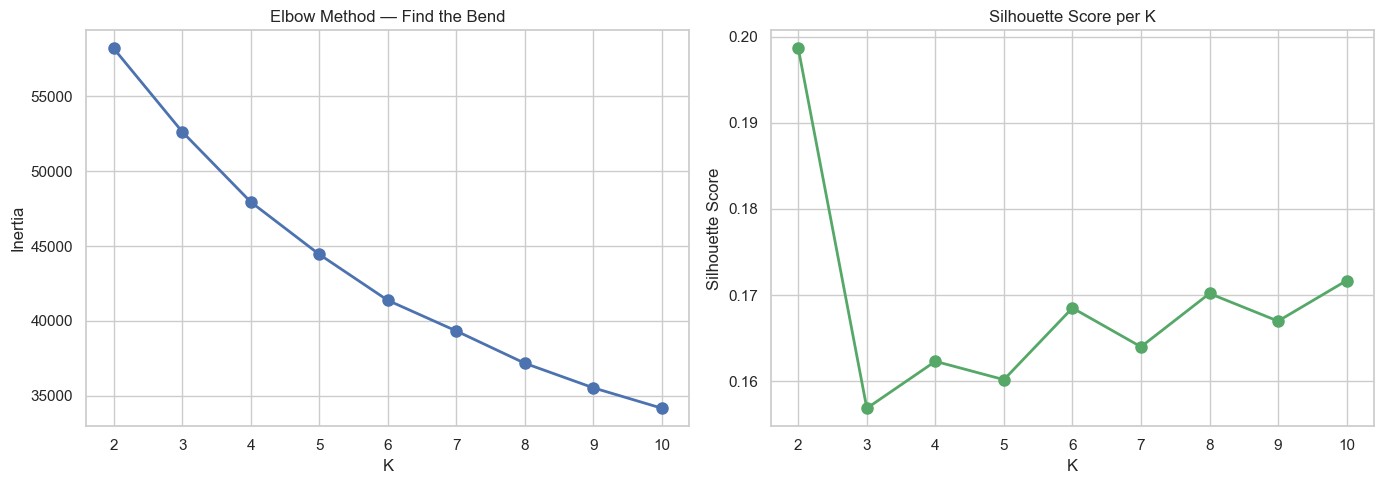


✅ Best K = 2  (Silhouette = 0.1986)


In [5]:
inertia    = []
sil_scores = []
K_range    = range(2, 11)

print('Testing K values...')
for k in K_range:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(df_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(df_scaled, labels))
    print(f'  K={k}  Inertia={km.inertia_:.0f}  Silhouette={sil_scores[-1]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertia, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method — Find the Bend')

axes[1].plot(K_range, sil_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score per K')

plt.tight_layout()
plt.savefig('data/kmeans_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

best_k = list(K_range)[sil_scores.index(max(sil_scores))]
print(f'\n✅ Best K = {best_k}  (Silhouette = {max(sil_scores):.4f})')

In [6]:
K        = best_k
km_final = KMeans(n_clusters=K, random_state=42, n_init=10)
km_labels = km_final.fit_predict(df_scaled)

df_result           = df_clean.copy()
df_result['Cluster'] = km_labels

print(f'K-Means trained with K={K}')
print('\nCluster sizes:')
print(df_result['Cluster'].value_counts().sort_index())

K-Means trained with K=2

Cluster sizes:
Cluster
0    4650
1    3418
Name: count, dtype: int64


In [7]:
sil = silhouette_score(df_scaled, km_labels)
dbs = davies_bouldin_score(df_scaled, km_labels)

print('=== K-Means Evaluation ===')
print(f'K                   : {K}')
print(f'Silhouette Score    : {sil:.4f}  (higher = better, max 1.0)')
print(f'Davies-Bouldin Score: {dbs:.4f}  (lower  = better, min 0.0)')
print(f'Inertia             : {km_final.inertia_:.2f}')

scores = {'algorithm': 'K-Means', 'n_clusters': K,
          'silhouette': round(sil, 4), 'davies_bouldin': round(dbs, 4),
          'inertia': round(km_final.inertia_, 2), 'noise': 0}
pickle.dump(scores,    open('data/kmeans_scores.pkl', 'wb'))
pickle.dump(km_labels, open('data/kmeans_labels.pkl', 'wb'))
print('\n✅ Scores saved!')

=== K-Means Evaluation ===
K                   : 2
Silhouette Score    : 0.1986  (higher = better, max 1.0)
Davies-Bouldin Score: 1.9329  (lower  = better, min 0.0)
Inertia             : 58198.83

✅ Scores saved!


Variance explained by 2 components: 41.1%


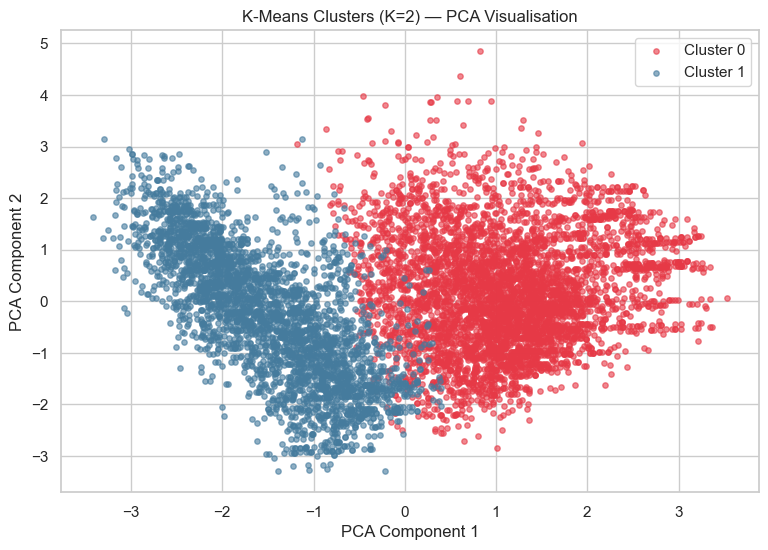

In [8]:
pca    = PCA(n_components=2, random_state=42)
df_pca = pca.fit_transform(df_scaled)
print(f'Variance explained by 2 components: {pca.explained_variance_ratio_.sum()*100:.1f}%')

colors = ['#E63946','#457B9D','#2A9D8F','#E9C46A','#F4A261','#264653','#7B2D8B']

plt.figure(figsize=(9, 6))
for i in range(K):
    mask = km_labels == i
    plt.scatter(df_pca[mask, 0], df_pca[mask, 1],
                s=15, color=colors[i % len(colors)],
                label=f'Cluster {i}', alpha=0.6)

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title(f'K-Means Clusters (K={K}) — PCA Visualisation')
plt.legend()
plt.savefig('data/kmeans_pca.png', dpi=150, bbox_inches='tight')
plt.show()

=== Cluster Profiles (Mean Values) ===
         Gender  Ever_Married    Age  Graduated  Profession  Work_Experience  \
Cluster                                                                        
0          0.40          1.00  51.99       0.72        2.43             2.16   
1          0.52          0.04  31.88       0.50        3.18             2.90   

         Spending_Score  Family_Size  Var_1  
Cluster                                      
0                  0.95         2.74   4.27  
1                  0.00         3.01   3.98  


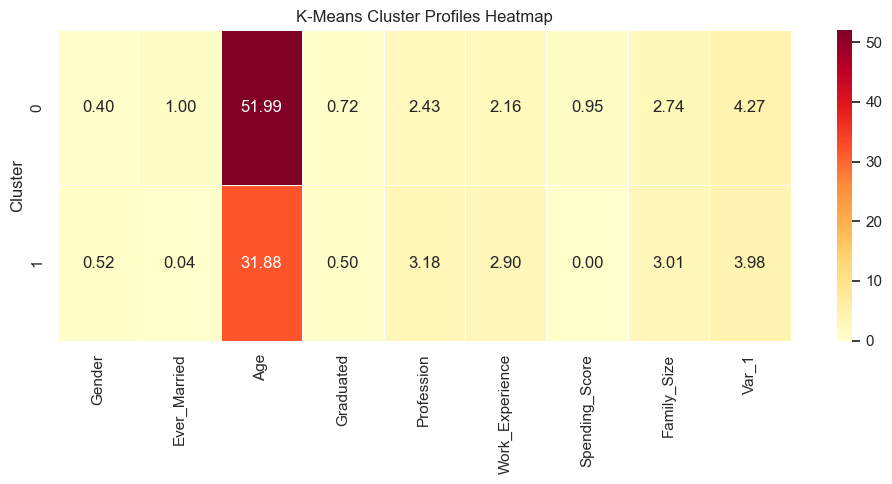

In [9]:
# Cluster profiles heatmap
profile = df_result.groupby('Cluster').mean().round(2)
print('=== Cluster Profiles (Mean Values) ===')
print(profile)

plt.figure(figsize=(10, 5))
sns.heatmap(profile, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5)
plt.title('K-Means Cluster Profiles Heatmap')
plt.tight_layout()
plt.savefig('data/kmeans_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

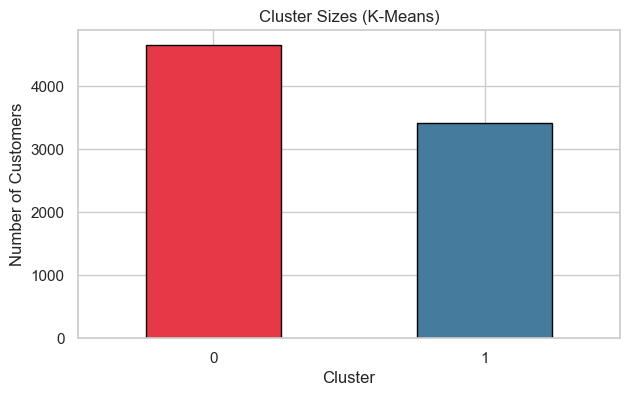

In [10]:
# Cluster size bar chart
plt.figure(figsize=(7, 4))
df_result['Cluster'].value_counts().sort_index().plot(
    kind='bar', color=colors[:K], edgecolor='black')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.title('Cluster Sizes (K-Means)')
plt.xticks(rotation=0)
plt.savefig('data/kmeans_sizes.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
print('=' * 55)
print('   K-MEANS: Predict Cluster for a New Customer')
print('=' * 55)
print('Enter customer details below (press Enter after each):\n')
print('Profession codes : 0=Artist, 1=Doctor, 2=Engineer,')
print('                   3=Entertainment, 4=Executive,')
print('                   5=Healthcare, 6=Homemaker,')
print('                   7=Lawyer, 8=Marketing')
print('Var_1 codes      : 0 to 6 (category code)')
print()

age            = float(input('Age (e.g. 30): '))
gender         = float(input('Gender        — Male=0, Female=1: '))
ever_married   = float(input('Ever Married  — No=0, Yes=1: '))
graduated      = float(input('Graduated     — No=0, Yes=1: '))
profession     = float(input('Profession    — (enter code 0–8): '))
work_exp       = float(input('Work Experience (years, e.g. 5): '))
spending_score = float(input('Spending Score — Low=0, Average=1, High=2: '))
family_size    = float(input('Family Size   (e.g. 3): '))
var_1          = float(input('Var_1         — (enter code 0–6): '))

# Build array in same order as df_clean columns
user_data   = np.array([[age, gender, ever_married, graduated,
                          profession, work_exp, spending_score,
                          family_size, var_1]])

# Scale using the same scaler from preprocessing
user_scaled = scaler.transform(user_data)

# Predict cluster
predicted_cluster = km_final.predict(user_scaled)[0]

# Show result
profile = df_result.groupby('Cluster').mean().round(2)

print()
print('=' * 55)
print(f'  ✅ Predicted Cluster: Cluster {predicted_cluster}')
print('=' * 55)
print(f'\nAverage profile of Cluster {predicted_cluster}:')
print(profile.loc[predicted_cluster].to_string())
print('\n👉 This customer belongs to the group above.')

   K-MEANS: Predict Cluster for a New Customer
Enter customer details below (press Enter after each):

Profession codes : 0=Artist, 1=Doctor, 2=Engineer,
                   3=Entertainment, 4=Executive,
                   5=Healthcare, 6=Homemaker,
                   7=Lawyer, 8=Marketing
Var_1 codes      : 0 to 6 (category code)



Age (e.g. 30):  20
Gender        — Male=0, Female=1:  1
Ever Married  — No=0, Yes=1:  0
Graduated     — No=0, Yes=1:  1
Profession    — (enter code 0–8):  3
Work Experience (years, e.g. 5):  4
Spending Score — Low=0, Average=1, High=2:  2
Family Size   (e.g. 3):  2
Var_1         — (enter code 0–6):  1



  ✅ Predicted Cluster: Cluster 1

Average profile of Cluster 1:
Gender              0.52
Ever_Married        0.04
Age                31.88
Graduated           0.50
Profession          3.18
Work_Experience     2.90
Spending_Score      0.00
Family_Size         3.01
Var_1               3.98

👉 This customer belongs to the group above.
